In [39]:
import xgboost as xgb
import pandas as pd
import numpy as np
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import root_mean_squared_error
import matplotlib.pyplot as plt
import random

In [40]:
SEED = 42 #For later
random.seed(SEED)   # Python’s random
np.random.seed(SEED)

#Create DataFrame with TSLA

In [41]:
TICKER = "TSLA"
START = "2015-01-01"
END = "2024-01-01" #leave 2025 for model test

def load_data(ticker=TICKER, start=START, end=END):
    import yfinance as yf
    df = yf.download(ticker, start=start, end=end, progress=False)
    df.index = pd.to_datetime(df.index)
    return df


In [42]:
df = load_data()
df.sort_values(by='Date') #sort the data
df.columns = df.columns.droplevel(1) #drop 'Ticker TSLA TSLA..' row
columns_titles = ["Open", "Low", "High", "Close", "Volume"] #swap close and open row
df=df.reindex(columns=columns_titles)
print(len(df))
df.tail()

2264


/tmp/ipykernel_2377/364227606.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download(ticker, start=start, end=end, progress=False)


Price,Open,Low,High,Close,Volume
Date,,,,,
2023-12-22,256.760010,251.369995,258.220001,252.539993,93370100
2023-12-26,254.490005,252.910004,257.970001,256.609985,86892400
2023-12-27,258.350006,257.519989,263.339996,261.440002,106494400
2023-12-28,263.660004,252.710007,265.130005,253.179993,113619900
2023-12-29,255.100006,247.429993,255.190002,248.479996,100891600


#Time Series Split

In [49]:
#function returns folds based on any given df of a particular stock.
def createTimeSeriesSplit(data, n_splits = 5, test_size = 90, gap = 3):
    tss = TimeSeriesSplit(n_splits = n_splits, test_size = test_size, gap = gap)

    folds = [] 
    for k, (train_idx, test_idx) in enumerate(tss.split(data)): #enum to add k folds 
        folds.append({
            "fold": k,
            "train_idx": train_idx.tolist(),  
            "test_idx": test_idx.tolist(),
        })
    return folds
def previewFold(fold: list):
    for k in fold:
        print("fold:", k["fold"], "\ntrain_idx", k["train_idx"][:20], "...", k["train_idx"][-20:], 
                        "\ntest_idex", k["test_idx"][:20], "...", k["test_idx"][-15:])

#create time series split
fold = createTimeSeriesSplit(df, 5, 90, 3)
#checking 
previewFold(fold)


fold: 0 
train_idx [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19] ... [1791, 1792, 1793, 1794, 1795, 1796, 1797, 1798, 1799, 1800, 1801, 1802, 1803, 1804, 1805, 1806, 1807, 1808, 1809, 1810] 
test_idex [1814, 1815, 1816, 1817, 1818, 1819, 1820, 1821, 1822, 1823, 1824, 1825, 1826, 1827, 1828, 1829, 1830, 1831, 1832, 1833] ... [1889, 1890, 1891, 1892, 1893, 1894, 1895, 1896, 1897, 1898, 1899, 1900, 1901, 1902, 1903]
fold: 1 
train_idx [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19] ... [1881, 1882, 1883, 1884, 1885, 1886, 1887, 1888, 1889, 1890, 1891, 1892, 1893, 1894, 1895, 1896, 1897, 1898, 1899, 1900] 
test_idex [1904, 1905, 1906, 1907, 1908, 1909, 1910, 1911, 1912, 1913, 1914, 1915, 1916, 1917, 1918, 1919, 1920, 1921, 1922, 1923] ... [1979, 1980, 1981, 1982, 1983, 1984, 1985, 1986, 1987, 1988, 1989, 1990, 1991, 1992, 1993]
fold: 2 
train_idx [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19] ... [1971, 1972, 1973, 197

#Model

In [48]:
'''
Given the base parameters of the xgboost model, time series split, and stock data
Return [1] the model on the last fold 
       [2] model predictions, test sets, and rmse scores for fine-tuning hyperparameters
'''
FEATURES = ["Open", "Low", "High"]
TARGET = ["Close"]

def train_xgb(base_params=None, tss=None, data=None):

    # Use default one if user did not provide any hyperparameters
    if not base_params:
        base_params = {"n_estimators": 100, "early_stopping_rounds": 50, 
                       "max_depth": 3, "random_state":SEED, "objective":'reg:squarederror'}

    preds, tests = [], []
    scores = []
    for train_idx, test_idx in tss.split(data):
        train = data.iloc[train_idx]
        test = data.iloc[test_idx]
    
        X_train = train[FEATURES]
        y_train = train[TARGET]
        X_test = test[FEATURES]
        y_test = test[TARGET]
            
        reg = xgb.XGBRegressor(**base_params)
        reg.fit(X_train, y_train, eval_set=[(X_train,y_train), (X_test, y_test)], verbose=100)
        
        y_pred = reg.predict(X_test)
        y_pred = pd.Series(y_pred, index=y_test.index)
        
        tests.append(y_test)
        preds.append(y_pred)
        score = root_mean_squared_error(y_test, y_pred)
        scores.append(score)

    return reg, preds, tests, scores

In [52]:
reg, preds, tests, scores = train_xgb(tss=tss, data=df)
print(f"Average Errors: {np.mean(scores):.4f}")

[0]	validation_0-rmse:68.42065	validation_1-rmse:149.21844


[99]	validation_0-rmse:1.67503	validation_1-rmse:6.68765
[0]	validation_0-rmse:73.86945	validation_1-rmse:125.21464
[99]	validation_0-rmse:1.77422	validation_1-rmse:4.83510
[0]	validation_0-rmse:76.76791	validation_1-rmse:61.25867
[99]	validation_0-rmse:1.87152	validation_1-rmse:5.46283
[0]	validation_0-rmse:76.18461	validation_1-rmse:98.98093
[99]	validation_0-rmse:1.81130	validation_1-rmse:3.92459
[0]	validation_0-rmse:77.10624	validation_1-rmse:102.31442
[99]	validation_0-rmse:1.91921	validation_1-rmse:3.56641
Average Errors: 4.8782


#Plot

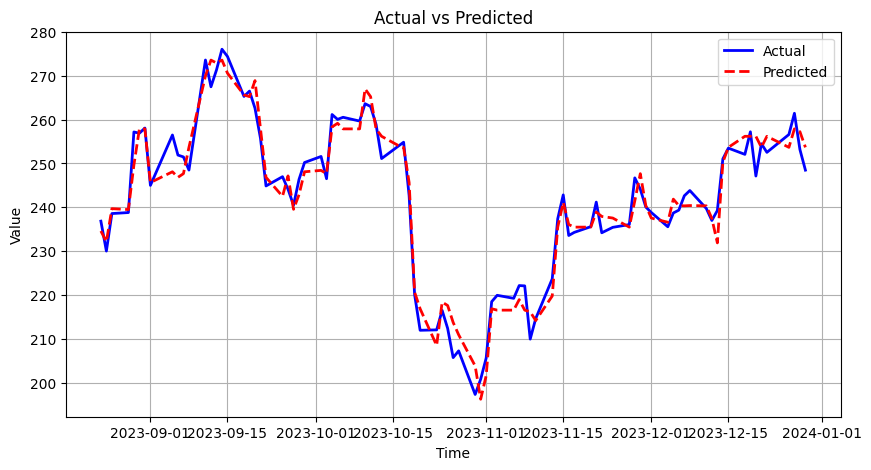

In [46]:
# Plot the actual results vs. model prediction for the most recent period
plt.figure(figsize=(10,5))
plt.plot(tests[-1], label='Actual', color='blue', linewidth=2)
plt.plot(preds[-1], label='Predicted', color='red', linestyle='--', linewidth=2)
plt.title('Actual vs Predicted')
plt.xlabel('Time')
plt.ylabel('Value')
plt.legend()
plt.grid(True)
plt.show()